# MD-GRTN Phase 1 — PEMS08 Traffic Prediction
**Architecture:** MDAF (BackNet denoiser + MAF) → MGRC (GCN+GRU, dual adjacency) → Spatial Transformer × L → Temporal Transformer × L

> Phase 1: Recent sequence only. Phase 2 (multi-period) will add yesterday + 1-week branches.

In [1]:
# Run this cell first on Colab
# !pip install torch numpy -q  # already available on Colab
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch: 2.10.0+cu128
CUDA available: True


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class Config:
    # ── data ──
    data_path    = "/content/PEMS08.npz"
    num_nodes    = 170
    in_features  = 3               # flow, occupancy, speed
    seq_len      = 12
    pred_len     = 12
    feature_idx  = 0               # predict flow channel

    # ── model ──
    d_model    = 64
    n_heads    = 4
    num_layers = 2                 # L spatial + L temporal layers
    gru_layers = 4                 # stacked GCN+GRU layers
    dropout    = 0.1

    # ── training ──
    batch_size  = 32
    lr          = 1e-3
    epochs      = 100
    patience    = 15
    train_ratio = 0.6
    val_ratio   = 0.2

cfg = Config()
print('Config ready.')

Config ready.


In [3]:
def load_pems08(cfg):
    raw  = np.load(cfg.data_path)
    print('Keys in npz:', list(raw.keys()))
    data = raw['data'].astype(np.float32)      # (T, N, F)
    print(f'Raw data shape: {data.shape}')
    T, N, F = data.shape

    # global z-score normalisation
    mean = data.mean(axis=(0,1), keepdims=True)
    std  = data.std(axis=(0,1),  keepdims=True) + 1e-8
    data = (data - mean) / std

    # adjacency matrix
    if 'adjacency_matrix' in raw:
        A_dist = raw['adjacency_matrix'].astype(np.float32)
    elif 'adj_mx' in raw:
        A_dist = raw['adj_mx'].astype(np.float32)
    else:
        print('No adjacency matrix found — using identity.')
        A_dist = np.eye(N, dtype=np.float32)
    deg    = A_dist.sum(axis=1, keepdims=True) + 1e-8
    A_dist = A_dist / deg

    return data, mean, std, A_dist


class TrafficDataset(Dataset):
    def __init__(self, data, seq_len, pred_len, feature_idx):
        self.data      = torch.from_numpy(data)
        self.seq_len   = seq_len
        self.pred_len  = pred_len
        self.feat_idx  = feature_idx
        self.length    = len(data) - seq_len - pred_len + 1

    def __len__(self):
        return self.length

    def __getitem__(self, i):
        x = self.data[i : i + self.seq_len]
        y = self.data[i + self.seq_len : i + self.seq_len + self.pred_len,
                      :, self.feat_idx]
        return x, y


def build_dataloaders(cfg):
    data, mean, std, A_dist = load_pems08(cfg)
    T  = len(data)
    t1 = int(T * cfg.train_ratio)
    t2 = int(T * (cfg.train_ratio + cfg.val_ratio))

    ds_tr = TrafficDataset(data[:t1],  cfg.seq_len, cfg.pred_len, cfg.feature_idx)
    ds_va = TrafficDataset(data[t1:t2],cfg.seq_len, cfg.pred_len, cfg.feature_idx)
    ds_te = TrafficDataset(data[t2:],  cfg.seq_len, cfg.pred_len, cfg.feature_idx)

    dl_tr = DataLoader(ds_tr, batch_size=cfg.batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_va = DataLoader(ds_va, batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True)
    dl_te = DataLoader(ds_te, batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return dl_tr, dl_va, dl_te, mean, std, A_dist

print('Data utilities ready.')

Data utilities ready.


In [4]:
# ─────────────────────────────────────────────
# MDAF: Multi-period Diffusion Attention Fusion
#   BackNet = MLP denoiser  (backward process)
#   MAF     = multi-head attention fusion
# ─────────────────────────────────────────────

class BackNet(nn.Module):
    """MLP denoiser — removes noise from each time-step feature."""
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, in_dim),
        )
    def forward(self, x):          # x: (B, S, N, F)
        return self.net(x)


class MultiHeadAttentionFusion(nn.Module):
    """Project each sequence, attend over nodes, concat + FC."""
    def __init__(self, in_dim, d_model, n_heads, n_seqs=1):
        super().__init__()
        self.projs  = nn.ModuleList([nn.Linear(in_dim, d_model) for _ in range(n_seqs)])
        self.attn   = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.fc_out = nn.Linear(d_model * n_seqs, d_model)

    def forward(self, seqs):       # list of (B, S, N, F)
        B, S, N, _ = seqs[0].shape
        projected = []
        for proj, seq in zip(self.projs, seqs):
            h = proj(seq.reshape(B*S, N, -1))    # (B*S, N, d)
            h, _ = self.attn(h, h, h)
            projected.append(h.reshape(B, S, N, -1))
        fused = torch.cat(projected, dim=-1)      # (B, S, N, d*n_seqs)
        return self.fc_out(fused)                 # (B, S, N, d)


class MDModule(nn.Module):
    def __init__(self, in_features, d_model, n_seqs=1):
        super().__init__()
        self.backnets = nn.ModuleList([BackNet(in_features, d_model) for _ in range(n_seqs)])
    def forward(self, seqs):
        return [bn(s) for bn, s in zip(self.backnets, seqs)]


class MDAFModule(nn.Module):
    def __init__(self, in_features, d_model, n_heads, n_seqs=1):
        super().__init__()
        self.md  = MDModule(in_features, d_model, n_seqs)
        self.maf = MultiHeadAttentionFusion(in_features, d_model, n_heads, n_seqs)
    def forward(self, seqs):       # list of (B,S,N,F) → (B,S,N,d)
        cleaned = self.md(seqs)
        return self.maf(cleaned)

print('MDAF module defined.')

MDAF module defined.


In [5]:
# ─────────────────────────────────────────────
# MGRC: Multi-Graph Recurrent Convolution
#   A_dyna (learnable) + A_dist (fixed) → 1x1 Conv → A_F
#   Stacked GCN + GRU layers
# ─────────────────────────────────────────────

class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)
    def forward(self, x, A):       # x:(B,N,d), A:(N,N)
        ax = torch.einsum('nm,bmd->bnd', A, x)
        return self.lin(ax)


class GCN_GRU_Layer(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.gcn = GraphConv(in_dim, hidden_dim)
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)

    def forward(self, x_seq, A):   # x_seq:(B,S,N,d) → (B,S,N,hid)
        B, S, N, _ = x_seq.shape
        h = torch.zeros(B*N, self.gru.hidden_size, device=x_seq.device)
        outs = []
        for t in range(S):
            x_t     = x_seq[:, t]                        # (B,N,d)
            gcn_out = F.relu(self.gcn(x_t, A))           # (B,N,hid)
            h       = self.gru(gcn_out.reshape(B*N, -1), h)
            outs.append(h.reshape(B, N, -1))
        return torch.stack(outs, dim=1)                   # (B,S,N,hid)


class MGRCModule(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_nodes, num_layers=4):
        super().__init__()
        self.emb      = nn.Parameter(torch.randn(num_nodes, hidden_dim))
        self.adj_conv = nn.Conv2d(2, 1, kernel_size=1)
        self.layers   = nn.ModuleList()
        self.layers.append(GCN_GRU_Layer(in_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.layers.append(GCN_GRU_Layer(hidden_dim, hidden_dim))

    def get_fused_adj(self, A_dist_t):
        A_dyna  = torch.softmax(self.emb @ self.emb.T, dim=-1)
        stacked = torch.stack([A_dist_t, A_dyna], dim=0).unsqueeze(0)  # (1,2,N,N)
        A_F     = self.adj_conv(stacked).squeeze(0).squeeze(0)          # (N,N)
        A_F     = F.relu(A_F)
        return A_F / (A_F.sum(-1, keepdim=True) + 1e-8)

    def forward(self, x, A_dist):  # (B,S,N,d) → (B,S,N,hid)
        A_F = self.get_fused_adj(A_dist)
        for layer in self.layers:
            x = layer(x, A_F)
        return x

print('MGRC module defined.')

MGRC module defined.


In [6]:
# ─────────────────────────────────────────────
# Spatial Transformer  — attends over N nodes
# Temporal Transformer — attends over S steps
# ─────────────────────────────────────────────

class SpatialTransformerLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d_model, d_model*4), nn.ReLU(), nn.Linear(d_model*4, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):          # (B,S,N,d)
        B, S, N, d = x.shape
        f = x.reshape(B*S, N, d)
        h, _ = self.attn(f, f, f)
        h = self.norm1(f + self.drop(h))
        h = self.norm2(h + self.drop(self.ff(h)))
        return h.reshape(B, S, N, d)


class TemporalTransformerLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d_model, d_model*4), nn.ReLU(), nn.Linear(d_model*4, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):          # (B,S,N,d)
        B, S, N, d = x.shape
        f = x.permute(0,2,1,3).reshape(B*N, S, d)
        h, _ = self.attn(f, f, f)
        h = self.norm1(f + self.drop(h))
        h = self.norm2(h + self.drop(self.ff(h)))
        return h.reshape(B, N, S, d).permute(0,2,1,3)

print('Transformer layers defined.')

Transformer layers defined.


In [7]:
# ─────────────────────────────────────────────
# Full MD-GRTN Model
# ─────────────────────────────────────────────

class MDGRTN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        N, F, d = cfg.num_nodes, cfg.in_features, cfg.d_model
        L, h, dr = cfg.num_layers, cfg.n_heads, cfg.dropout
        P, S = cfg.pred_len, cfg.seq_len

        self.mdaf = MDAFModule(F, d, h, n_seqs=1)
        self.mgrc = MGRCModule(d, d, N, num_layers=cfg.gru_layers)

        self.spatial_pos  = nn.Parameter(torch.randn(1, 1, N, d))
        self.temporal_pos = nn.Parameter(torch.randn(1, S, 1, d))

        self.spatial_layers  = nn.ModuleList([SpatialTransformerLayer(d, h, dr)  for _ in range(L)])
        self.temporal_layers = nn.ModuleList([TemporalTransformerLayer(d, h, dr) for _ in range(L)])

        self.out_proj = nn.Linear(d * S, P)

    def forward(self, x_recent, A_dist):
        """x_recent: (B,S,N,F),  A_dist: (N,N)  →  (B,P,N)"""
        x = self.mdaf([x_recent])                              # (B,S,N,d)
        x = self.mgrc(x, A_dist)                              # (B,S,N,d)
        x = x + self.spatial_pos
        for layer in self.spatial_layers:
            x = layer(x)
        x = x + self.temporal_pos
        for layer in self.temporal_layers:
            x = layer(x)
        B, S, N, d = x.shape
        x   = x.permute(0,2,1,3).reshape(B, N, S*d)
        out = self.out_proj(x)                                 # (B,N,P)
        return out.permute(0,2,1)                              # (B,P,N)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MDGRTN(cfg).to(device)
total  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model ready on {device}  |  Parameters: {total:,}')

Model ready on cuda  |  Parameters: 369,682


In [8]:
def masked_mae(pred, true, null_val=0.0):
    mask = (true != null_val).float()
    return (torch.abs(pred - true) * mask).sum() / (mask.sum() + 1e-8)

def masked_rmse(pred, true, null_val=0.0):
    mask = (true != null_val).float()
    return torch.sqrt(((pred - true)**2 * mask).sum() / (mask.sum() + 1e-8))

def masked_mape(pred, true, null_val=0.0, eps=1e-8):
    mask = (true.abs() > eps).float()
    return (torch.abs((pred - true) / (true.abs() + eps)) * mask).sum() / (mask.sum() + 1e-8) * 100

print('Metrics defined.')

Metrics defined.


In [9]:
# ── Mount Google Drive if using Colab ──
# from google.colab import drive
# drive.mount('/content/drive')
# cfg.data_path = '/content/drive/MyDrive/PEMS08.npz'

dl_train, dl_val, dl_test, mean_np, std_np, A_dist_np = build_dataloaders(cfg)

mean_flow = torch.tensor(float(mean_np[0, 0, cfg.feature_idx]), device=device)
std_flow  = torch.tensor(float(std_np [0, 0, cfg.feature_idx]), device=device)
A_dist    = torch.from_numpy(A_dist_np).to(device)

print(f'Train batches: {len(dl_train)} | Val: {len(dl_val)} | Test: {len(dl_test)}')

Keys in npz: ['data']
Raw data shape: (17856, 170, 3)
No adjacency matrix found — using identity.
Train batches: 335 | Val: 111 | Test: 111


In [10]:
def train_epoch(model, loader, optimizer, A_dist, device):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x, A_dist)
        loss = masked_mae(pred, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, A_dist, device, mean_flow, std_flow):
    model.eval()
    maes, rmses, mapes = [], [], []
    for x, y in loader:
        x, y   = x.to(device), y.to(device)
        pred   = model(x, A_dist)
        pred_d = pred * std_flow + mean_flow
        y_d    = y    * std_flow + mean_flow
        maes.append(masked_mae(pred_d, y_d).item())
        rmses.append(masked_rmse(pred_d, y_d).item())
        mapes.append(masked_mape(pred_d, y_d).item())
    return np.mean(maes), np.mean(rmses), np.mean(mapes)

print('Train/eval functions defined.')

Train/eval functions defined.


In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

best_val_mae  = float('inf')
patience_cnt  = 0
history       = {'train_loss': [], 'val_mae': [], 'val_rmse': [], 'val_mape': []}

for epoch in range(1, cfg.epochs + 1):
    train_loss            = train_epoch(model, dl_train, optimizer, A_dist, device)
    val_mae, val_rmse, val_mape = eval_epoch(model, dl_val, A_dist, device, mean_flow, std_flow)
    scheduler.step(val_mae)

    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_mape'].append(val_mape)

    print(f'Epoch {epoch:03d} | Loss={train_loss:.4f} | Val MAE={val_mae:.3f}  RMSE={val_rmse:.3f}  MAPE={val_mape:.2f}%')

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        patience_cnt = 0
        torch.save(model.state_dict(), 'best_mdgrtn_phase1.pt')
        print('  ✓ Best model saved.')
    else:
        patience_cnt += 1
        if patience_cnt >= cfg.patience:
            print('Early stopping triggered.')
            break

Epoch 001 | Loss=0.2733 | Val MAE=23.626  RMSE=33.371  MAPE=20.82%
  ✓ Best model saved.
Epoch 002 | Loss=0.1533 | Val MAE=21.698  RMSE=30.701  MAPE=22.56%
  ✓ Best model saved.
Epoch 003 | Loss=0.1403 | Val MAE=20.351  RMSE=29.674  MAPE=16.52%
  ✓ Best model saved.
Epoch 004 | Loss=0.1334 | Val MAE=28.399  RMSE=37.957  MAPE=18.37%
Epoch 005 | Loss=0.1318 | Val MAE=19.513  RMSE=28.530  MAPE=15.51%
  ✓ Best model saved.
Epoch 006 | Loss=0.1277 | Val MAE=21.821  RMSE=30.636  MAPE=15.76%
Epoch 007 | Loss=0.1236 | Val MAE=20.522  RMSE=29.100  MAPE=14.11%
Epoch 008 | Loss=0.1237 | Val MAE=19.127  RMSE=27.723  MAPE=15.27%
  ✓ Best model saved.
Epoch 009 | Loss=0.1201 | Val MAE=18.266  RMSE=26.754  MAPE=14.14%
  ✓ Best model saved.
Epoch 010 | Loss=0.1201 | Val MAE=22.681  RMSE=31.928  MAPE=15.54%
Epoch 011 | Loss=0.1184 | Val MAE=18.898  RMSE=27.521  MAPE=16.11%
Epoch 012 | Loss=0.1162 | Val MAE=23.730  RMSE=32.107  MAPE=17.76%
Epoch 013 | Loss=0.1169 | Val MAE=20.158  RMSE=28.264  MAPE=19.4

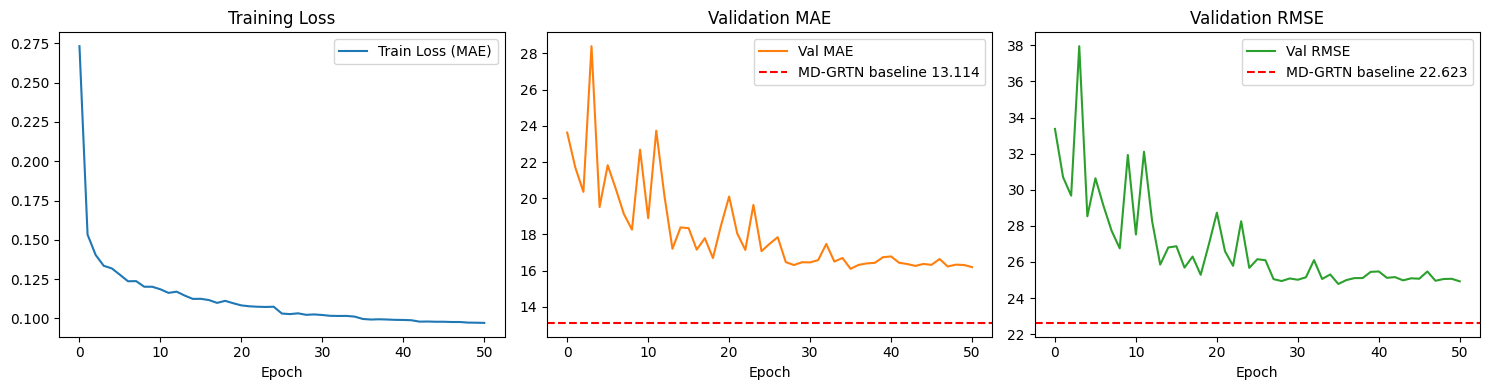

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train Loss (MAE)')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['val_mae'],  label='Val MAE',  color='tab:orange')
axes[1].axhline(y=13.114, color='red', linestyle='--', label='MD-GRTN baseline 13.114')
axes[1].set_title('Validation MAE'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['val_rmse'], label='Val RMSE', color='tab:green')
axes[2].axhline(y=22.623, color='red', linestyle='--', label='MD-GRTN baseline 22.623')
axes[2].set_title('Validation RMSE'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [15]:
model.load_state_dict(torch.load('best_mdgrtn_phase1.pt', map_location=device))
test_mae, test_rmse, test_mape = eval_epoch(model, dl_test, A_dist, device, mean_flow, std_flow)


print(f'  Test MAE  : {test_mae:.3f}')
print(f'  Test RMSE : {test_rmse:.3f}')
print(f'  Test MAPE : {test_mape:.2f}%')


  Test MAE  : 15.735
  Test RMSE : 23.780
  Test MAPE : 10.17%
